# Schema

In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az
import pymc_marketing
from pymc_marketing.clv import ParetoNBDModel, BetaGeoModel

from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score

#from tqdm import tqdm
#import re
#import os
#from tqdm.notebook import tqdm

#from sentence_transformers import SentenceTransformer
#from sklearn.cluster import KMeans,MiniBatchKMeans, AgglomerativeClustering
#from sklearn.metrics import silhouette_score

In [4]:
df = pd.read_csv('clean_purchase.csv')

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 799406 entries, 0 to 799405
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   line_id      799406 non-null  int64         
 1   Invoice      799406 non-null  int64         
 2   StockCode    799406 non-null  str           
 3   Description  799406 non-null  str           
 4   Quantity     799406 non-null  int64         
 5   InvoiceDate  799406 non-null  datetime64[us]
 6   Price        799406 non-null  float64       
 7   Customer ID  799406 non-null  int64         
 8   Country      799406 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(4), str(3)
memory usage: 54.9 MB


In [6]:
df['line_amount'] = df['Price']*df['Quantity']

In [7]:
# Group by customer and invoice, then sum the costs and quantities
df_invoice = df.groupby(['Invoice', 'Customer ID','InvoiceDate', 'Country']).agg(
    total_amount=('line_amount', 'sum'),
    number_of_items=('Quantity', 'sum')
).reset_index()

In [8]:
### Creating product table

df_product = (
    df.groupby('StockCode', as_index=False)['Description']
      .first()
)

In [9]:
df.drop(columns=['Customer ID','InvoiceDate', 'Country', 'Description'], inplace=True)

df.to_csv('line.csv', index=False)
df_invoice.to_csv("invoice.csv", index=False)
df_product.to_csv('product.csv', index=False)

df.info()
df_invoice.info()
df_product.info()

<class 'pandas.DataFrame'>
RangeIndex: 799406 entries, 0 to 799405
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   line_id      799406 non-null  int64  
 1   Invoice      799406 non-null  int64  
 2   StockCode    799406 non-null  str    
 3   Quantity     799406 non-null  int64  
 4   Price        799406 non-null  float64
 5   line_amount  799406 non-null  float64
dtypes: float64(2), int64(3), str(1)
memory usage: 36.6 MB
<class 'pandas.DataFrame'>
RangeIndex: 36728 entries, 0 to 36727
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Invoice          36728 non-null  int64         
 1   Customer ID      36728 non-null  int64         
 2   InvoiceDate      36728 non-null  datetime64[us]
 3   Country          36728 non-null  str           
 4   total_amount     36728 non-null  float64       
 5   number_of_items  36728 no

In [10]:
# Determine split date (2/3 of the time span)
min_date = df_invoice['InvoiceDate'].min()
max_date = df_invoice['InvoiceDate'].max()

split_date = min_date + (max_date - min_date) * (2/3)

print(f"Split date: {split_date}")

# Split into calibration and holdout
df_calibration = df_invoice[df_invoice['InvoiceDate'] < split_date].copy()
df_holdout = df_invoice[df_invoice['InvoiceDate'] >= split_date].copy()

print("Calibration:", df_calibration.shape)
print("Holdout:", df_holdout.shape)

print("Calibration period:")
print(df_calibration['InvoiceDate'].min(), "to", df_calibration['InvoiceDate'].max())

print("Holdout period:")
print(df_holdout['InvoiceDate'].min(), "to", df_holdout['InvoiceDate'].max())

Split date: 2011-04-07 11:08:20
Calibration: (23224, 6)
Holdout: (13504, 6)
Calibration period:
2009-12-01 07:45:00 to 2011-04-07 11:06:00
Holdout period:
2011-04-07 11:12:00 to 2011-12-09 12:50:00


In [11]:

# make sure dates are datetime
df_calibration = df_calibration.copy()
df_calibration['InvoiceDate'] = pd.to_datetime(df_calibration['InvoiceDate'])

cal_end = df_calibration['InvoiceDate'].max()

# sort so "first" and "repeat" purchases are well-defined
tmp = df_calibration.sort_values(['Customer ID', 'InvoiceDate', 'Invoice']).copy()
tmp['purchase_no'] = tmp.groupby('Customer ID').cumcount()

# customer-level summary
df_cal_summary = (
    tmp.groupby('Customer ID')
       .agg(
           first_purchase=('InvoiceDate', 'min'),
           last_purchase=('InvoiceDate', 'max'),
           number_of_transactions=('Invoice', 'nunique'),
       )
)

# BG/NBD fields
df_cal_summary['frequency'] = df_cal_summary['number_of_transactions'] - 1
df_cal_summary['recency'] = (
    df_cal_summary['last_purchase'] - df_cal_summary['first_purchase']
).dt.days
df_cal_summary['T'] = (
    cal_end - df_cal_summary['first_purchase']
).dt.days

# monetary_value = mean order value of repeat purchases only
repeat_spend = (
    tmp[tmp['purchase_no'] > 0]
    .groupby('Customer ID')['total_amount']
    .mean()
)

df_cal_summary['monetary_value'] = repeat_spend

# optional: reorder columns
df_cal_summary = df_cal_summary[
    ['frequency', 'recency', 'T', 'monetary_value',
     'first_purchase', 'last_purchase', 'number_of_transactions']
]

print(df_cal_summary.shape)
print(df_cal_summary.head())
print(df_cal_summary.describe())

(4727, 7)
             frequency  recency    T  monetary_value      first_purchase  \
Customer ID                                                                
12346               10      196  479       32.786000 2009-12-14 08:34:00   
12347                3      157  157      845.073333 2010-10-31 14:20:00   
12348                3      189  191      495.746667 2010-09-27 14:59:00   
12349                2      181  342      801.310000 2010-04-29 13:20:00   
12350                0        0   63             NaN 2011-02-02 16:01:00   

                  last_purchase  number_of_transactions  
Customer ID                                              
12346       2010-06-28 13:53:00                      11  
12347       2011-04-07 10:43:00                       4  
12348       2011-04-05 10:47:00                       4  
12349       2010-10-28 08:23:00                       3  
12350       2011-02-02 16:01:00                       1  
         frequency      recency            T  monet

In [12]:
# keep this for Gamma-Gamma later
df_cal_summary_gg = df_cal_summary[df_cal_summary['frequency'] > 0].copy()


In [13]:
print('freq: ',(df_cal_summary['frequency'] == 0).sum())
print('monetary_value',df_cal_summary['monetary_value'].isna().sum())

freq:  1568
monetary_value 1564


In [14]:
df_cal_summary[
    (df_cal_summary['frequency'] > 0)
    & (df_cal_summary['monetary_value'].isna())
]

,frequency,recency,T,monetary_value,first_purchase,last_purchase,number_of_transactions
Customer ID,,,,,,,


In [15]:
df_calibration.groupby('Customer ID')['Invoice'].nunique().describe()

count    4727.000000
mean        4.902687
std         9.302383
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       231.000000
Name: Invoice, dtype: float64

In [16]:
df_calibration[
    df_calibration['Customer ID'] == 12346
].sort_values('InvoiceDate')

,Invoice,Customer ID,InvoiceDate,Country,total_amount,number_of_items
1002,491725,12346,2009-12-14 08:34:00,UNITED KINGDOM,45.00,10
1013,491742,12346,2009-12-14 11:00:00,UNITED KINGDOM,22.50,5
1015,491744,12346,2009-12-14 11:02:00,UNITED KINGDOM,22.50,5
1355,492718,12346,2009-12-18 10:47:00,UNITED KINGDOM,22.50,5
1357,492722,12346,2009-12-18 10:55:00,UNITED KINGDOM,1.00,1
1505,493410,12346,2010-01-04 09:24:00,UNITED KINGDOM,22.50,5
1506,493412,12346,2010-01-04 09:53:00,UNITED KINGDOM,22.50,5
1822,494450,12346,2010-01-14 13:50:00,UNITED KINGDOM,22.50,5
2117,495295,12346,2010-01-22 13:30:00,UNITED KINGDOM,22.50,5
3672,499763,12346,2010-03-02 13:08:00,UNITED KINGDOM,27.05,5


In [17]:
print((df_cal_summary['recency'] > df_cal_summary['T']).sum())
print((df_cal_summary['frequency'] < 0).sum())
print((df_cal_summary['T'] < 0).sum())

0
0
0


In [18]:
print(df_cal_summary[['frequency', 'recency', 'T']].describe())
print("Customers:", len(df_cal_summary))
print("Repeat buyers:", (df_cal_summary['frequency'] > 0).sum())
print("One-time buyers:", (df_cal_summary['frequency'] == 0).sum())

         frequency      recency            T
count  4727.000000  4727.000000  4727.000000
mean      3.902687   165.804527   315.870743
std       9.302383   166.196780   142.425648
min       0.000000     0.000000     0.000000
25%       0.000000     0.000000   188.000000
50%       1.000000   126.000000   346.000000
75%       4.000000   321.000000   439.000000
max     230.000000   491.000000   492.000000
Customers: 4727
Repeat buyers: 3159
One-time buyers: 1568


In [19]:
bgnbd_data = (
    df_cal_summary
    .reset_index()
    .rename(columns={'Customer ID': 'customer_id'})
    [['customer_id', 'frequency', 'recency', 'T']]
    .copy()
)

bgnbd_data.head()

,customer_id,frequency,recency,T
0,12346,10,196,479
1,12347,3,157,157
2,12348,3,189,191
3,12349,2,181,342
4,12350,0,0,63


In [20]:
print(bgnbd_data.shape)
print((bgnbd_data['recency'] > bgnbd_data['T']).sum())
print((bgnbd_data['frequency'] < 0).sum())
print((bgnbd_data['T'] < 0).sum())

(4727, 4)
0
0
0


In [21]:
model = BetaGeoModel(
    data=bgnbd_data,
    sampler_config={
        "progressbar": True
    }
)

model.fit(fit_method="map")

Output()

Inference data with groups:
	> posterior
	> observed_data
	> fit_data

In [22]:
model.fit_summary()

alpha            49.250
r                 0.632
phi_dropout       0.060
kappa_dropout     3.115
a                 0.188
b                 2.927
Name: value, dtype: float64

In [24]:
pred_180 = model.expected_purchases(
    data=bgnbd_data,
    future_t=180
)

df_pred_180 = pred_180.to_dataframe(name='pred_180d').reset_index()
df_pred_180.head()

,chain,draw,customer_id,pred_180d
0,0,0,12346,0.063074
1,0,0,12347,2.901885
2,0,0,12348,2.503768
3,0,0,12349,0.987476
4,0,0,12350,0.954634


In [25]:
df_cal_summary_pymc = (
    df_cal_summary
    .reset_index()
    .rename(columns={'Customer ID': 'customer_id'})
    .merge(df_pred_180[['customer_id', 'pred_180d']], on='customer_id', how='left')
)

df_cal_summary_pymc.head()

,customer_id,frequency,recency,T,monetary_value,first_purchase,last_purchase,number_of_transactions,pred_180d
0,12346,10,196,479,32.786000,2009-12-14 08:34:00,2010-06-28 13:53:00,11,0.063074
1,12347,3,157,157,845.073333,2010-10-31 14:20:00,2011-04-07 10:43:00,4,2.901885
2,12348,3,189,191,495.746667,2010-09-27 14:59:00,2011-04-05 10:47:00,4,2.503768
3,12349,2,181,342,801.310000,2010-04-29 13:20:00,2010-10-28 08:23:00,3,0.987476
4,12350,0,0,63,NaN,2011-02-02 16:01:00,2011-02-02 16:01:00,1,0.954634


In [26]:
df_cal_summary_pymc['pred_180d'].isna().sum()

np.int64(0)

In [27]:
df_cal_summary_pymc.sort_values(
    'pred_180d',
    ascending=False
).head(10)

,customer_id,frequency,recency,T,monetary_value,first_purchase,last_purchase,number_of_transactions,pred_180d
2024,14911,230,491,491,727.833420,2009-12-01 11:41:00,2011-04-07 10:33:00,231,74.658742
288,12748,178,482,488,155.624944,2009-12-04 17:31:00,2011-04-01 14:07:00,179,57.742010
2349,15311,148,491,491,513.897230,2009-12-01 11:21:00,2011-04-06 11:43:00,149,48.097208
1771,14606,133,488,489,175.130593,2009-12-03 12:40:00,2011-04-06 11:34:00,134,43.377989
563,13089,133,488,490,574.272707,2009-12-02 15:44:00,2011-04-05 13:52:00,134,43.277880
4374,17841,118,488,490,305.550593,2009-12-02 15:41:00,2011-04-05 15:00:00,119,38.415721
1398,14156,113,488,491,2022.301770,2009-12-01 12:30:00,2011-04-04 08:50:00,114,36.707162
1031,13694,106,482,488,1406.784340,2009-12-04 15:26:00,2011-04-01 11:46:00,107,34.541600
2147,15061,103,489,491,1038.112233,2009-12-01 12:18:00,2011-04-05 10:31:00,104,33.492806
4584,18102,92,479,492,4242.381739,2009-12-01 09:24:00,2011-03-25 14:06:00,93,29.404631


In [28]:
holdout_start = split_date
holdout_end = df_invoice['InvoiceDate'].max()

holdout_days = (holdout_end - holdout_start).days

print("Holdout start:", holdout_start)
print("Holdout end:", holdout_end)
print("Holdout days:", holdout_days)

Holdout start: 2011-04-07 11:08:20
Holdout end: 2011-12-09 12:50:00
Holdout days: 246


In [29]:
pred_holdout = model.expected_purchases(
    data=bgnbd_data,
    future_t=holdout_days
)

df_pred_holdout = (
    pred_holdout
    .to_dataframe(name='pred_holdout')
    .reset_index()
)

df_pred_holdout = df_pred_holdout[['customer_id', 'pred_holdout']]

df_pred_holdout.head()

,customer_id,pred_holdout
0,12346,0.085483
1,12347,3.907577
2,12348,3.376433
3,12349,1.337723
4,12350,1.283427


In [30]:
df_holdout = df_holdout.copy()
df_holdout['InvoiceDate'] = pd.to_datetime(df_holdout['InvoiceDate'])

actual_holdout = (
    df_holdout
    .groupby('Customer ID')
    .agg(actual_holdout=('Invoice', 'nunique'))
    .reset_index()
    .rename(columns={'Customer ID': 'customer_id'})
)

actual_holdout.head()

,customer_id,actual_holdout
0,12347,4
1,12348,1
2,12349,1
3,12352,3
4,12353,1


In [31]:
validation = (
    bgnbd_data
    .merge(df_pred_holdout, on='customer_id', how='left')
    .merge(actual_holdout, on='customer_id', how='left')
)

validation['actual_holdout'] = validation['actual_holdout'].fillna(0)

validation.head()

,customer_id,frequency,recency,T,pred_holdout,actual_holdout
0,12346,10,196,479,0.085483,0.0
1,12347,3,157,157,3.907577,4.0
2,12348,3,189,191,3.376433,1.0
3,12349,2,181,342,1.337723,1.0
4,12350,0,0,63,1.283427,0.0


In [32]:
print(validation.shape)
print(validation['pred_holdout'].isna().sum())
print(validation['actual_holdout'].isna().sum())

(4727, 6)
0
0


In [35]:
mae = mean_absolute_error(
    validation['actual_holdout'],
    validation['pred_holdout']
)

rmse = np.sqrt(
    mean_squared_error(
        validation['actual_holdout'],
        validation['pred_holdout']
    )
)

corr = validation[['actual_holdout', 'pred_holdout']].corr().iloc[0, 1]

print("MAE:", mae)
print("RMSE:", rmse)
print("Correlation:", corr)



total_actual = validation['actual_holdout'].sum()
total_predicted = validation['pred_holdout'].sum()

print("Total actual holdout purchases:", total_actual)
print("Total predicted holdout purchases:", total_predicted)
print("Prediction ratio:", total_predicted / total_actual)

MAE: 1.5284598330881056
RMSE: 2.885199499304306
Correlation: 0.8611602105370779
Total actual holdout purchases: 10883.0
Total predicted holdout purchases: 11009.284862742443
Prediction ratio: 1.0116038649951706


In [36]:
validation['pred_decile'] = pd.qcut(
    validation['pred_holdout'],
    q=10,
    labels=False,
    duplicates='drop'
)

decile_validation = (
    validation
    .groupby('pred_decile')
    .agg(
        customers=('customer_id', 'count'),
        avg_predicted=('pred_holdout', 'mean'),
        avg_actual=('actual_holdout', 'mean'),
        total_predicted=('pred_holdout', 'sum'),
        total_actual=('actual_holdout', 'sum')
    )
    .reset_index()
)

decile_validation

,pred_decile,customers,avg_predicted,avg_actual,total_predicted,total_actual
0,0,473,0.305686,0.287526,144.589381,136.0
1,1,481,0.483707,0.461538,232.663227,222.0
2,2,469,0.677515,0.727079,317.754434,341.0
3,3,468,0.842977,0.771368,394.513015,361.0
4,4,473,1.159162,0.995772,548.283407,471.0
5,5,472,1.510262,1.394068,712.843896,658.0
6,6,473,1.951691,1.697674,923.149987,803.0
7,7,472,2.556541,2.512712,1206.687256,1186.0
8,8,473,3.838133,3.591966,1815.436959,1699.0
9,9,473,9.964827,10.583510,4713.363302,5006.0


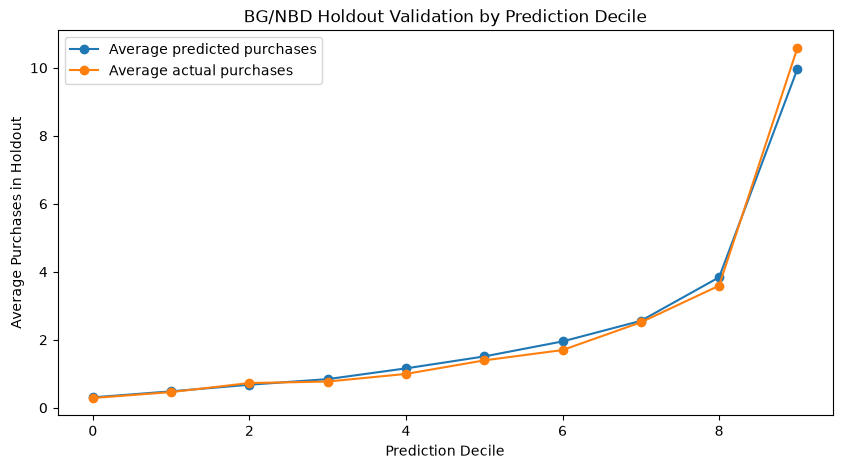

In [37]:
decile_plot = decile_validation.sort_values('pred_decile')

plt.figure(figsize=(10, 5))

plt.plot(
    decile_plot['pred_decile'],
    decile_plot['avg_predicted'],
    marker='o',
    label='Average predicted purchases'
)

plt.plot(
    decile_plot['pred_decile'],
    decile_plot['avg_actual'],
    marker='o',
    label='Average actual purchases'
)

plt.xlabel('Prediction Decile')
plt.ylabel('Average Purchases in Holdout')
plt.title('BG/NBD Holdout Validation by Prediction Decile')
plt.legend()
plt.show()

In [40]:
p_alive = model.expected_probability_alive(
    data=bgnbd_data
)

df_alive = (
    p_alive
    .to_dataframe(name='p_alive')
    .reset_index()
)

df_alive = df_alive[['customer_id', 'p_alive']]

In [41]:
validation = (
    validation
    .merge(df_alive, on='customer_id', how='left')
)

In [42]:
validation['actual_active'] = (
    validation['actual_holdout'] > 0
).astype(int)

validation['actual_churned'] = (
    validation['actual_holdout'] == 0
).astype(int)

In [43]:
validation['pred_active'] = (
    validation['p_alive'] >= 0.5
).astype(int)

validation['pred_churned'] = (
    validation['p_alive'] < 0.5
).astype(int)

In [44]:
pd.crosstab(
    validation['actual_churned'],
    validation['pred_churned'],
    margins=True
)

pred_churned,0,1,All
actual_churned,,,
0,2589,87,2676
1,1905,146,2051
All,4494,233,4727


In [46]:
accuracy = accuracy_score(
    validation['actual_churned'],
    validation['pred_churned']
)

precision = precision_score(
    validation['actual_churned'],
    validation['pred_churned']
)

recall = recall_score(
    validation['actual_churned'],
    validation['pred_churned']
)

f1 = f1_score(
    validation['actual_churned'],
    validation['pred_churned']
)

print(accuracy, precision, recall, f1)

0.5785910725618786 0.6266094420600858 0.07118478790833739 0.12784588441331


In [49]:
# Option 1: allow pandas to drop duplicate bin edges
validation['p_alive_decile'] = pd.qcut(
    validation['p_alive'],
    10,
    labels=False,
    duplicates='drop'
)
validation.groupby('p_alive_decile')['actual_holdout'].mean()

p_alive_decile
0    1.090909
1    1.355180
2    1.622881
3    1.926004
4    2.562368
5    4.480932
6    2.497091
Name: actual_holdout, dtype: float64

## Pareto/NBD Model

In [51]:
pnbd = ParetoNBDModel(
    data=bgnbd_data
)

idata_pnbd = pnbd.fit(
    fit_method="map"
)

NameError: name 'ParetoNBDModel' is not defined

# ==========

In [ ]:
### Creating short description using product table

def clean_product_description(text):
    text = str(text).lower()

    # remove numbers and measurements
    text = re.sub(r'\b\d+\s*(cm|mm|m|inch|inches|oz|ml|l|kg|g)\b', ' ', text)
    text = re.sub(r'\b\d+\b', ' ', text)

    # remove punctuation
    text = re.sub(r'[^a-z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # words that usually do not define category
    noise_words = {
        'set', 'pack', 'piece', 'pieces', 'small', 'large', 'medium',
        'mini', 'big', 'assorted', 'colour', 'colours', 'red', 'blue',
        'green', 'pink', 'white', 'black', 'yellow', 'purple', 'orange',
        'brown', 'silver', 'gold', 'metal', 'wooden', 'wood', 'glass',
        'ceramic', 'paper', 'plastic', 'felt', 'cotton', 'cm', 'mm',
        'round', 'square', 'heart', 'star', 'vintage', 'retro'
    }

    words = text.split()
    words = [w for w in words if w not in noise_words]

    return ' '.join(words)

product_table['short_description'] = product_table['Description'].apply(
    clean_product_description
)